In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
from sklearn.preprocessing import MinMaxScaler,RobustScaler


In [46]:
df = pd.read_csv('data/klike_challenge_dataset.csv')

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   campaign_id          500 non-null    str    
 1   date                 500 non-null    str    
 2   platform             500 non-null    str    
 3   category             500 non-null    str    
 4   objective            500 non-null    str    
 5   target_audience_age  500 non-null    str    
 6   is_retargeting       500 non-null    bool   
 7   video_duration_s     461 non-null    float64
 8   format               500 non-null    str    
 9   has_subtitle         454 non-null    object 
 10  has_cta              500 non-null    bool   
 11  has_hook             500 non-null    bool   
 12  has_face             500 non-null    bool   
 13  text_density         500 non-null    str    
 14  music_voice_ratio    462 non-null    float64
 15  impressions          500 non-null    int64  
 16  c

In [48]:
df.describe()

,video_duration_s,music_voice_ratio,impressions,clicks,ctr,cpc,spend,conversions,revenue,roas,avg_watch_time_s,engagement_rate,klike_score
count,461.000000,462.000000,5.000000e+02,500.000000,500.000000,472.000000,500.000000,500.0000,475.000000,500.000000,473.000000,468.000000,500.0000
mean,19.392625,0.399848,1.537385e+05,3594.104000,0.070968,1.112903,4213.151620,131.3520,6367.936863,2.499000,10.664271,0.027952,60.1568
std,13.529351,0.202674,1.171736e+06,7018.212512,0.045302,1.955625,11573.975576,314.5654,19267.180696,3.592365,10.533275,0.023057,15.5891
min,5.000000,0.020000,1.000000e+03,4.000000,0.002200,0.050000,2.960000,0.0000,0.000000,0.000000,0.400000,0.001000,10.4000
25%,11.000000,0.230000,9.986000e+03,461.750000,0.033200,0.530000,313.452500,10.0000,262.175000,0.430000,4.700000,0.011100,49.7750
50%,16.000000,0.385000,2.324100e+04,1351.000000,0.062750,0.710000,1031.000000,34.5000,1201.050000,1.490000,7.700000,0.021400,60.5500
75%,25.000000,0.550000,5.517275e+04,3583.250000,0.104800,1.020000,2867.952500,111.0000,4189.025000,3.250000,13.900000,0.038800,71.9250
max,115.000000,0.920000,1.405276e+07,72545.000000,0.150000,26.050000,121226.100000,3666.0000,241597.290000,39.920000,108.000000,0.100000,99.1000


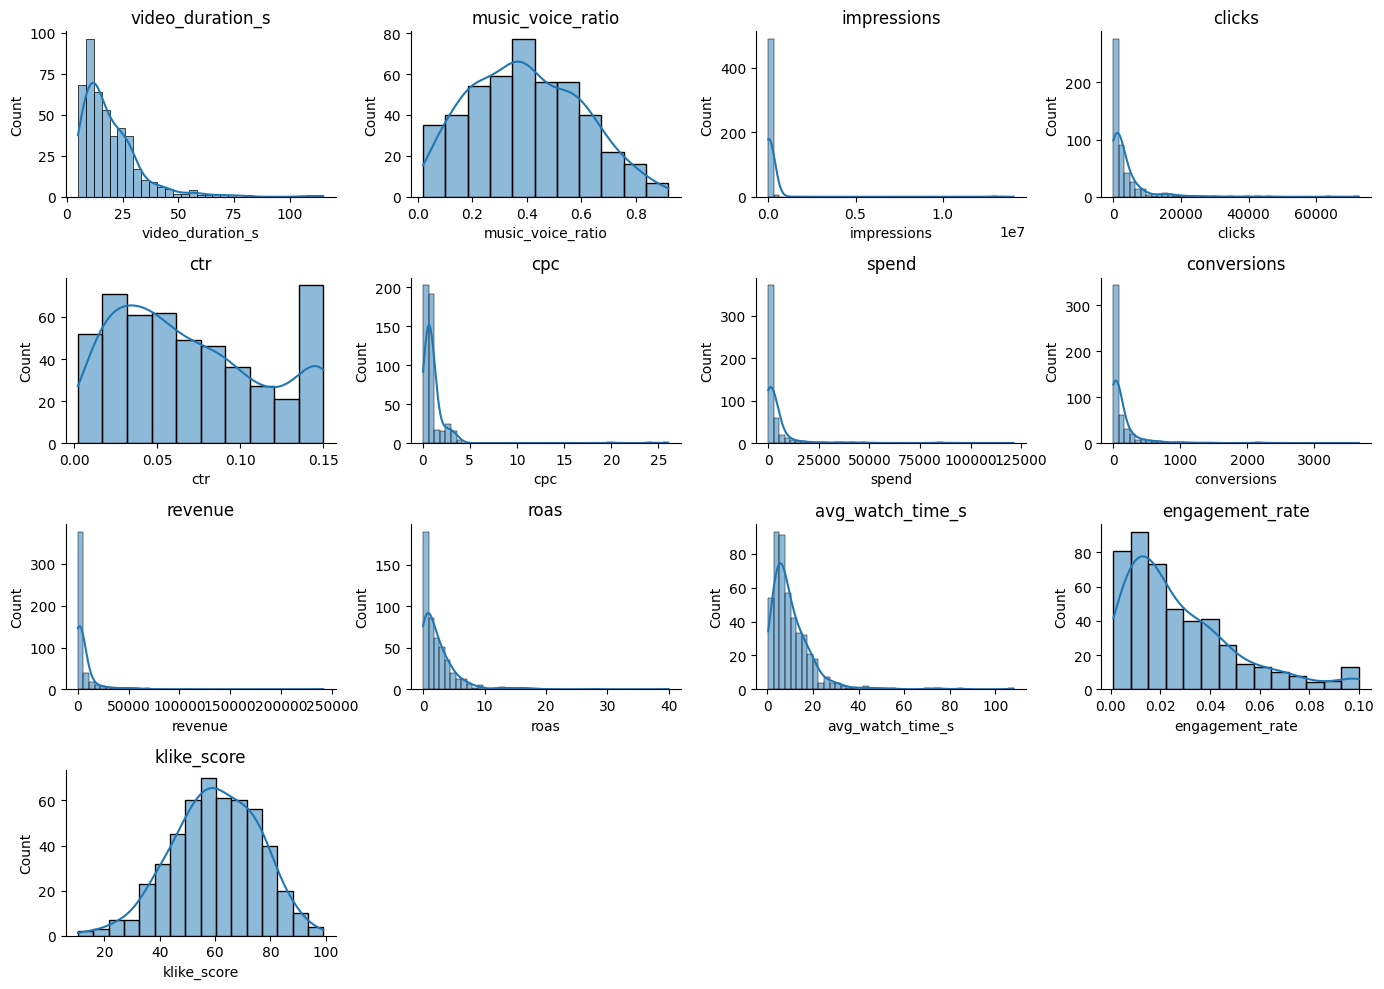

In [49]:
num_cols = df.select_dtypes(include='number').columns

fig, axes = plt.subplots(4, 4, figsize=(14,10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

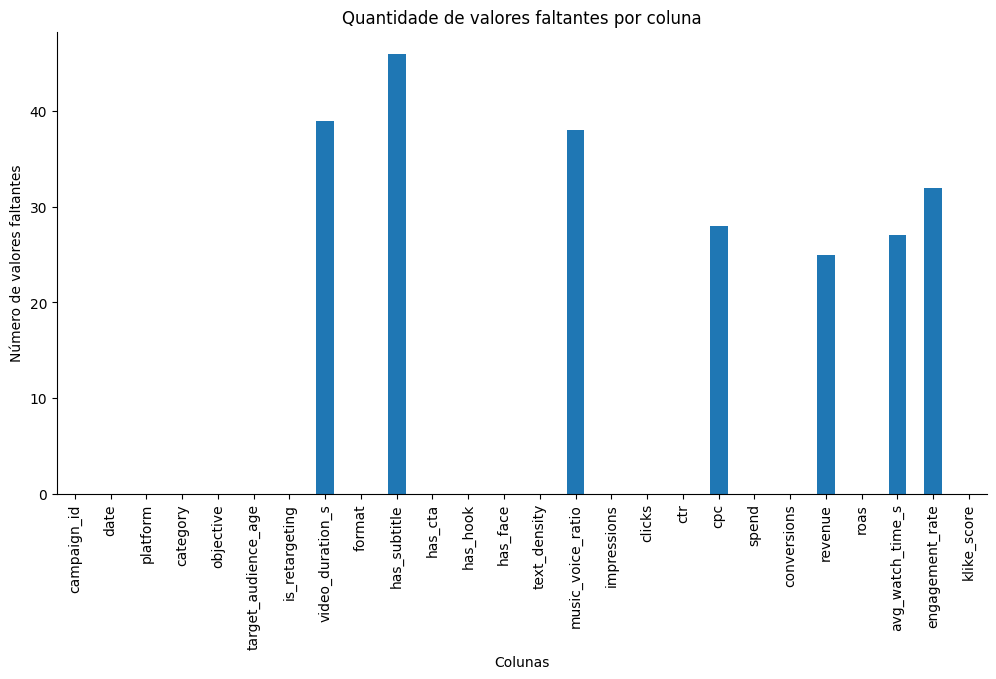

In [50]:
missing_counts = df.isna().sum()

# Plot
plt.figure(figsize=(12,6))
missing_counts.plot(kind='bar')
plt.title("Quantidade de valores faltantes por coluna")
plt.ylabel("Número de valores faltantes")
plt.xlabel("Colunas")
plt.show()

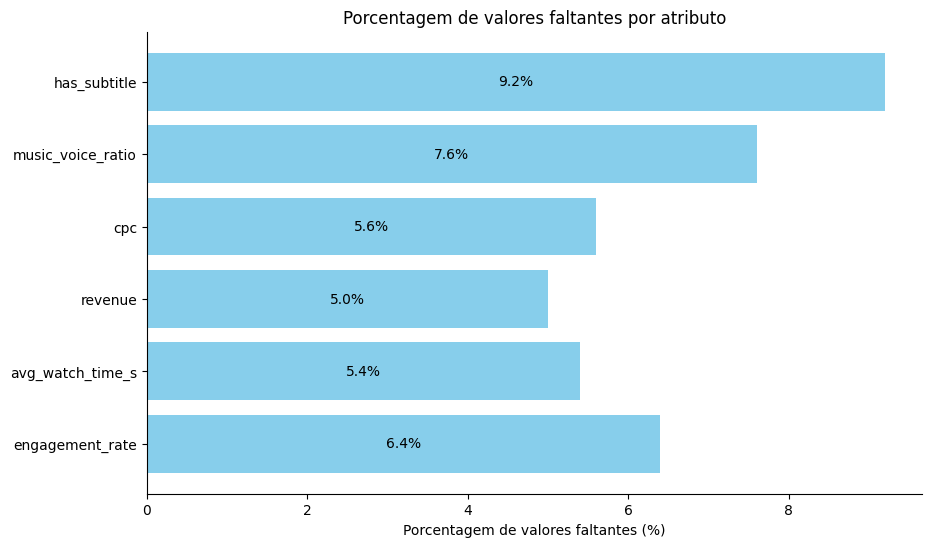

In [51]:
cols = [
    'has_subtitle',
    'music_voice_ratio',
    'cpc',
    'revenue',
    'avg_watch_time_s',
    'engagement_rate'
]

percentages = df[cols].isna().mean() * 100

plt.figure(figsize=(10,6))

bars = plt.barh(cols, percentages, color='skyblue')

plt.xlabel("Porcentagem de valores faltantes (%)")
plt.title("Porcentagem de valores faltantes por atributo")

for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    plt.text(
        width / 2,          # meio horizontal da barra
        y,
        f"{width:.1f}%",    # texto da porcentagem
        ha='center',
        va='center',
        fontsize=10,
        color='black'
    )

plt.gca().invert_yaxis()
plt.show()

## Tratamento de valores faltantes

In [52]:
# Qual % é nulo?
df['has_subtitle'].isnull().mean()

# Os nulos têm algum padrão? (ex: só em uma plataforma?)
df[df['has_subtitle'].isnull()]['platform'].value_counts()
df['has_subtitle'] = df['has_subtitle'].fillna(False)

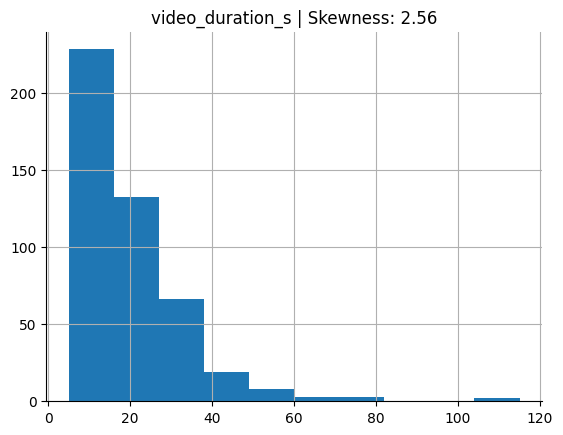

count    461.000000
mean      19.392625
std       13.529351
min        5.000000
25%       11.000000
50%       16.000000
75%       25.000000
max      115.000000
Name: video_duration_s, dtype: float64
Skewness: 2.555326978876786


In [53]:
# Skewness > 1 -> mediana
skew_val = df['video_duration_s'].skew()

fig, ax = plt.subplots()
df['video_duration_s'].hist(ax=ax)
ax.set_title(f'video_duration_s | Skewness: {skew_val:.2f}')
plt.show()

print(df['video_duration_s'].describe())
print(f"Skewness: {skew_val}")

# Preenche NaNs com a mediana da coluna
df['video_duration_s'] = df['video_duration_s'].fillna(df['video_duration_s'].median())

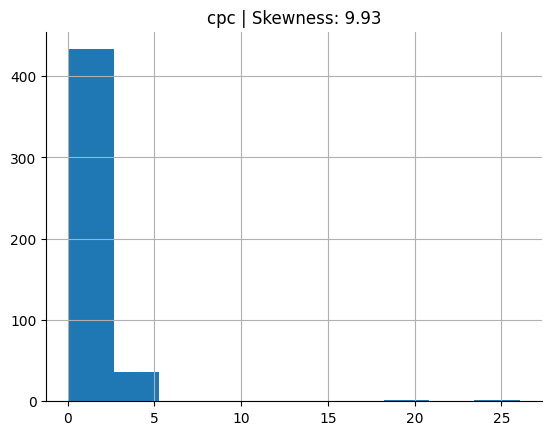

count    472.000000
mean       1.112903
std        1.955625
min        0.050000
25%        0.530000
50%        0.710000
75%        1.020000
max       26.050000
Name: cpc, dtype: float64
Skewness: 9.925325514170042


In [54]:
skew_val = df['cpc'].skew()

fig, ax = plt.subplots()
df['cpc'].hist(ax=ax)
ax.set_title(f'cpc | Skewness: {skew_val:.2f}')
plt.show()

print(df['cpc'].describe())
print(f"Skewness: {skew_val}")

df['cpc'] = df['cpc'].fillna(df['cpc'].median())

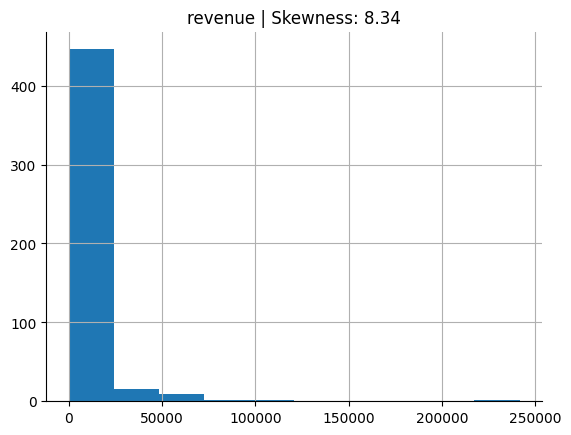

count       475.000000
mean       6367.936863
std       19267.180696
min           0.000000
25%         262.175000
50%        1201.050000
75%        4189.025000
max      241597.290000
Name: revenue, dtype: float64
Skewness: 8.343113090892805


In [55]:
skew_val = df['revenue'].skew()

fig, ax = plt.subplots()
df['revenue'].hist(ax=ax)
ax.set_title(f'revenue | Skewness: {skew_val:.2f}')
plt.show()

print(df['revenue'].describe())
print(f"Skewness: {skew_val}")

df['revenue'] = df['revenue'].fillna(df['revenue'].median())

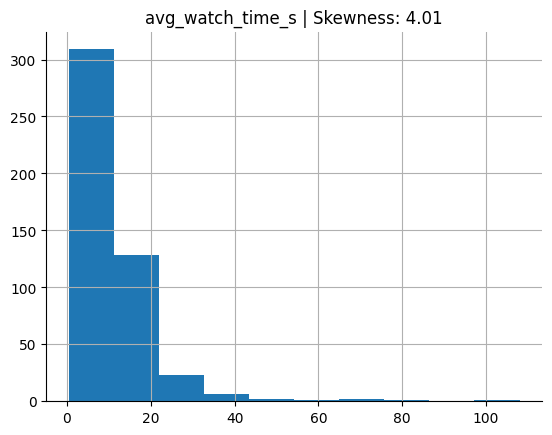

count    473.000000
mean      10.664271
std       10.533275
min        0.400000
25%        4.700000
50%        7.700000
75%       13.900000
max      108.000000
Name: avg_watch_time_s, dtype: float64
Skewness: 4.014319404951158


In [56]:
skew_val = df['avg_watch_time_s'].skew()

fig, ax = plt.subplots()
df['avg_watch_time_s'].hist(ax=ax)
ax.set_title(f'avg_watch_time_s | Skewness: {skew_val:.2f}')
plt.show()

print(df['avg_watch_time_s'].describe())
print(f"Skewness: {skew_val}")

df['avg_watch_time_s'] = df['avg_watch_time_s'].fillna(df['avg_watch_time_s'].median())

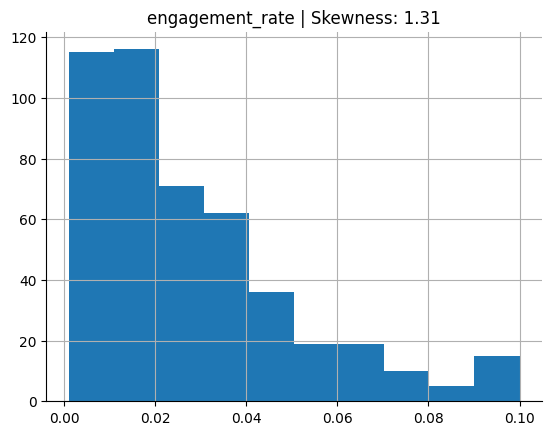

count    468.000000
mean       0.027952
std        0.023057
min        0.001000
25%        0.011100
50%        0.021400
75%        0.038800
max        0.100000
Name: engagement_rate, dtype: float64
Skewness: 1.3073316203723133


In [57]:
skew_val = df['engagement_rate'].skew()

fig, ax = plt.subplots()
df['engagement_rate'].hist(ax=ax)
ax.set_title(f'engagement_rate | Skewness: {skew_val:.2f}')
plt.show()

print(df['engagement_rate'].describe())
print(f"Skewness: {skew_val}")

df['engagement_rate'] = df['engagement_rate'].fillna(df['engagement_rate'].median())

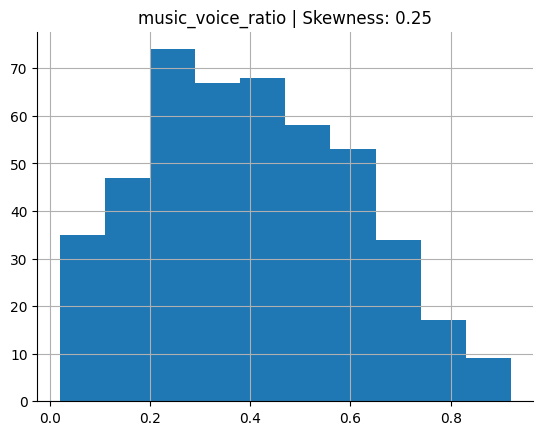

count    462.000000
mean       0.399848
std        0.202674
min        0.020000
25%        0.230000
50%        0.385000
75%        0.550000
max        0.920000
Name: music_voice_ratio, dtype: float64
Skewness: 0.24555145897923725


In [58]:
df['music_voice_ratio'].skew()
skew_val = df['music_voice_ratio'].skew()

fig, ax = plt.subplots()
df['music_voice_ratio'].hist(ax=ax)
ax.set_title(f'music_voice_ratio | Skewness: {skew_val:.2f}')
plt.show()

print(df['music_voice_ratio'].describe())
print(f"Skewness: {skew_val}")

df['music_voice_ratio'] = df['music_voice_ratio'].fillna(df['music_voice_ratio'].mean())

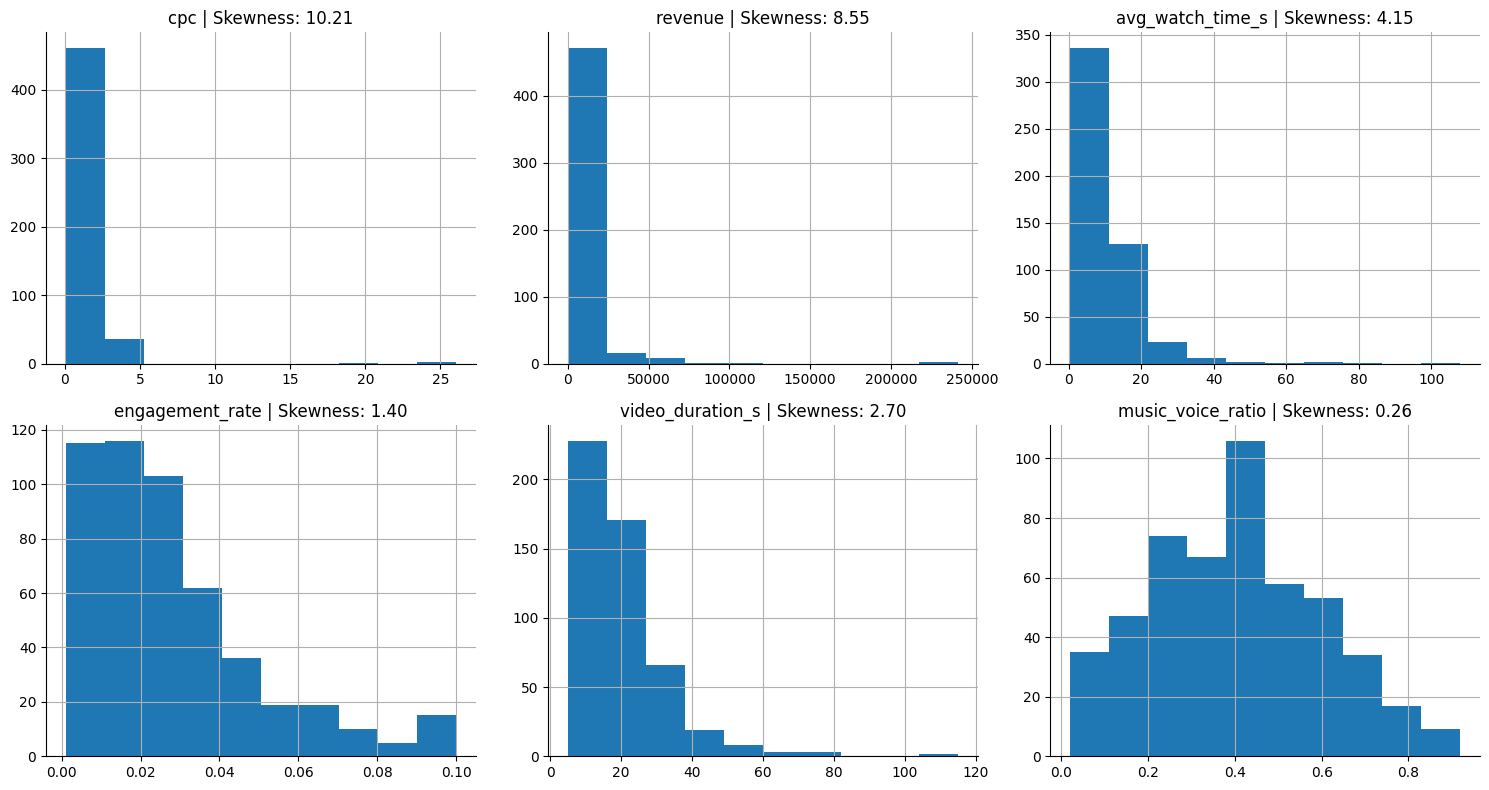

In [59]:
cols = ['cpc', 'revenue', 'avg_watch_time_s', 'engagement_rate', 'video_duration_s','music_voice_ratio']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    skew_val = df[col].skew()
    df[col].hist(ax=axes[i])
    axes[i].set_title(f'{col} | Skewness: {skew_val:.2f}')

plt.tight_layout()
plt.show()

## Outliers

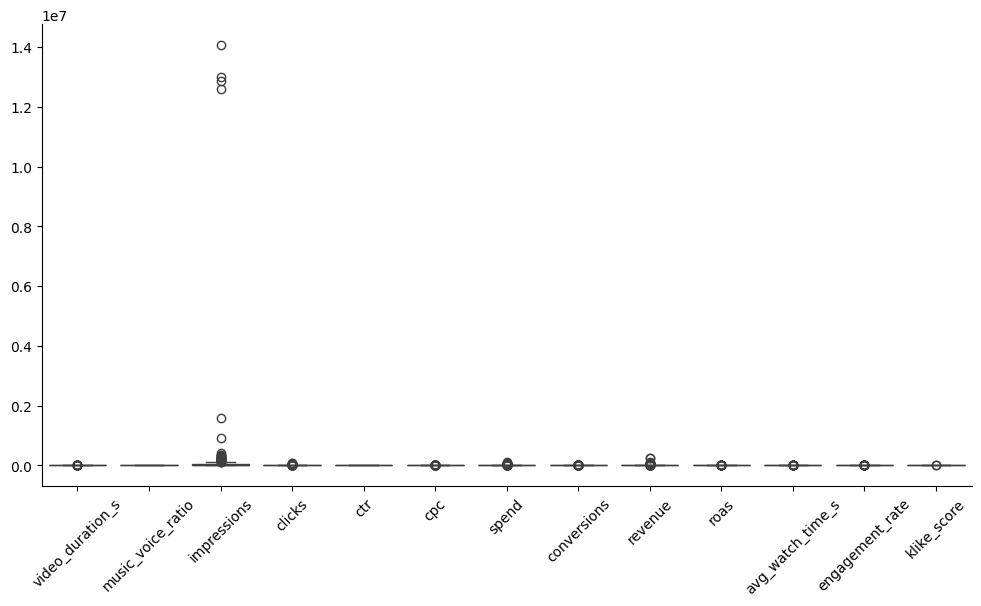

In [60]:
numeric_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)  # se os nomes forem longos
plt.show()

Colunas com maior diferença de magnitude: ['impressions', 'revenue', 'spend', 'clicks', 'conversions', 'video_duration_s']


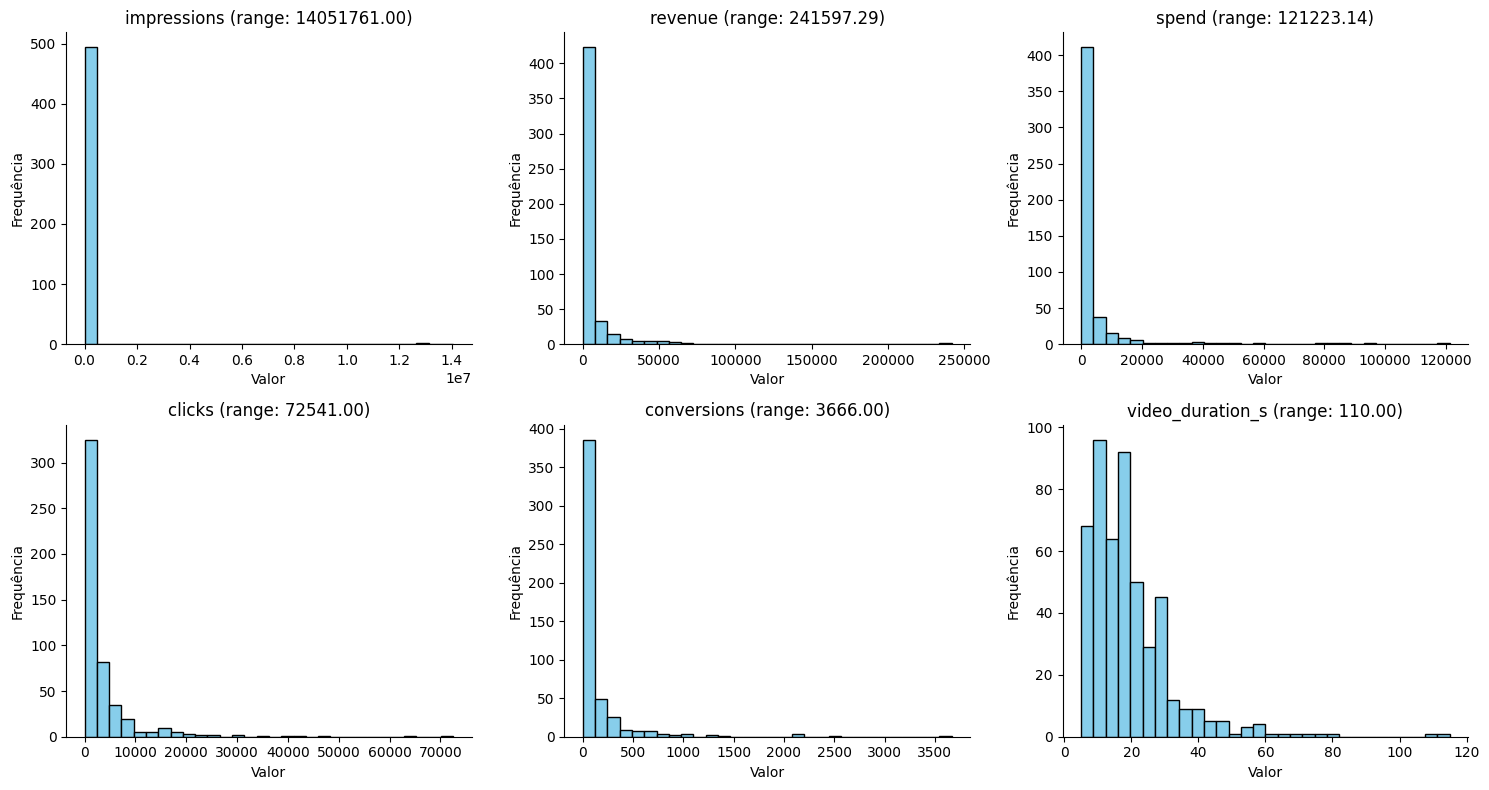

In [61]:
atributos = df.select_dtypes(include='number').columns

# Calcula a diferença entre máximo e mínimo
ranges = df[atributos].max() - df[atributos].min()

# Seleciona as top N colunas com maior diferença
top_n = 6
top_atributos = ranges.sort_values(ascending=False).head(top_n).index
print("Colunas com maior diferença de magnitude:", list(top_atributos))
n = len(top_atributos)
cols_subplot = 3
rows_subplot = math.ceil(n / cols_subplot)

plt.figure(figsize=(5*cols_subplot, 4*rows_subplot))
for i, col in enumerate(top_atributos, 1):
    plt.subplot(rows_subplot, cols_subplot, i)
    plt.hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black')
    plt.title(f"{col} (range: {ranges[col]:.2f})")
    plt.xlabel("Valor")
    plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

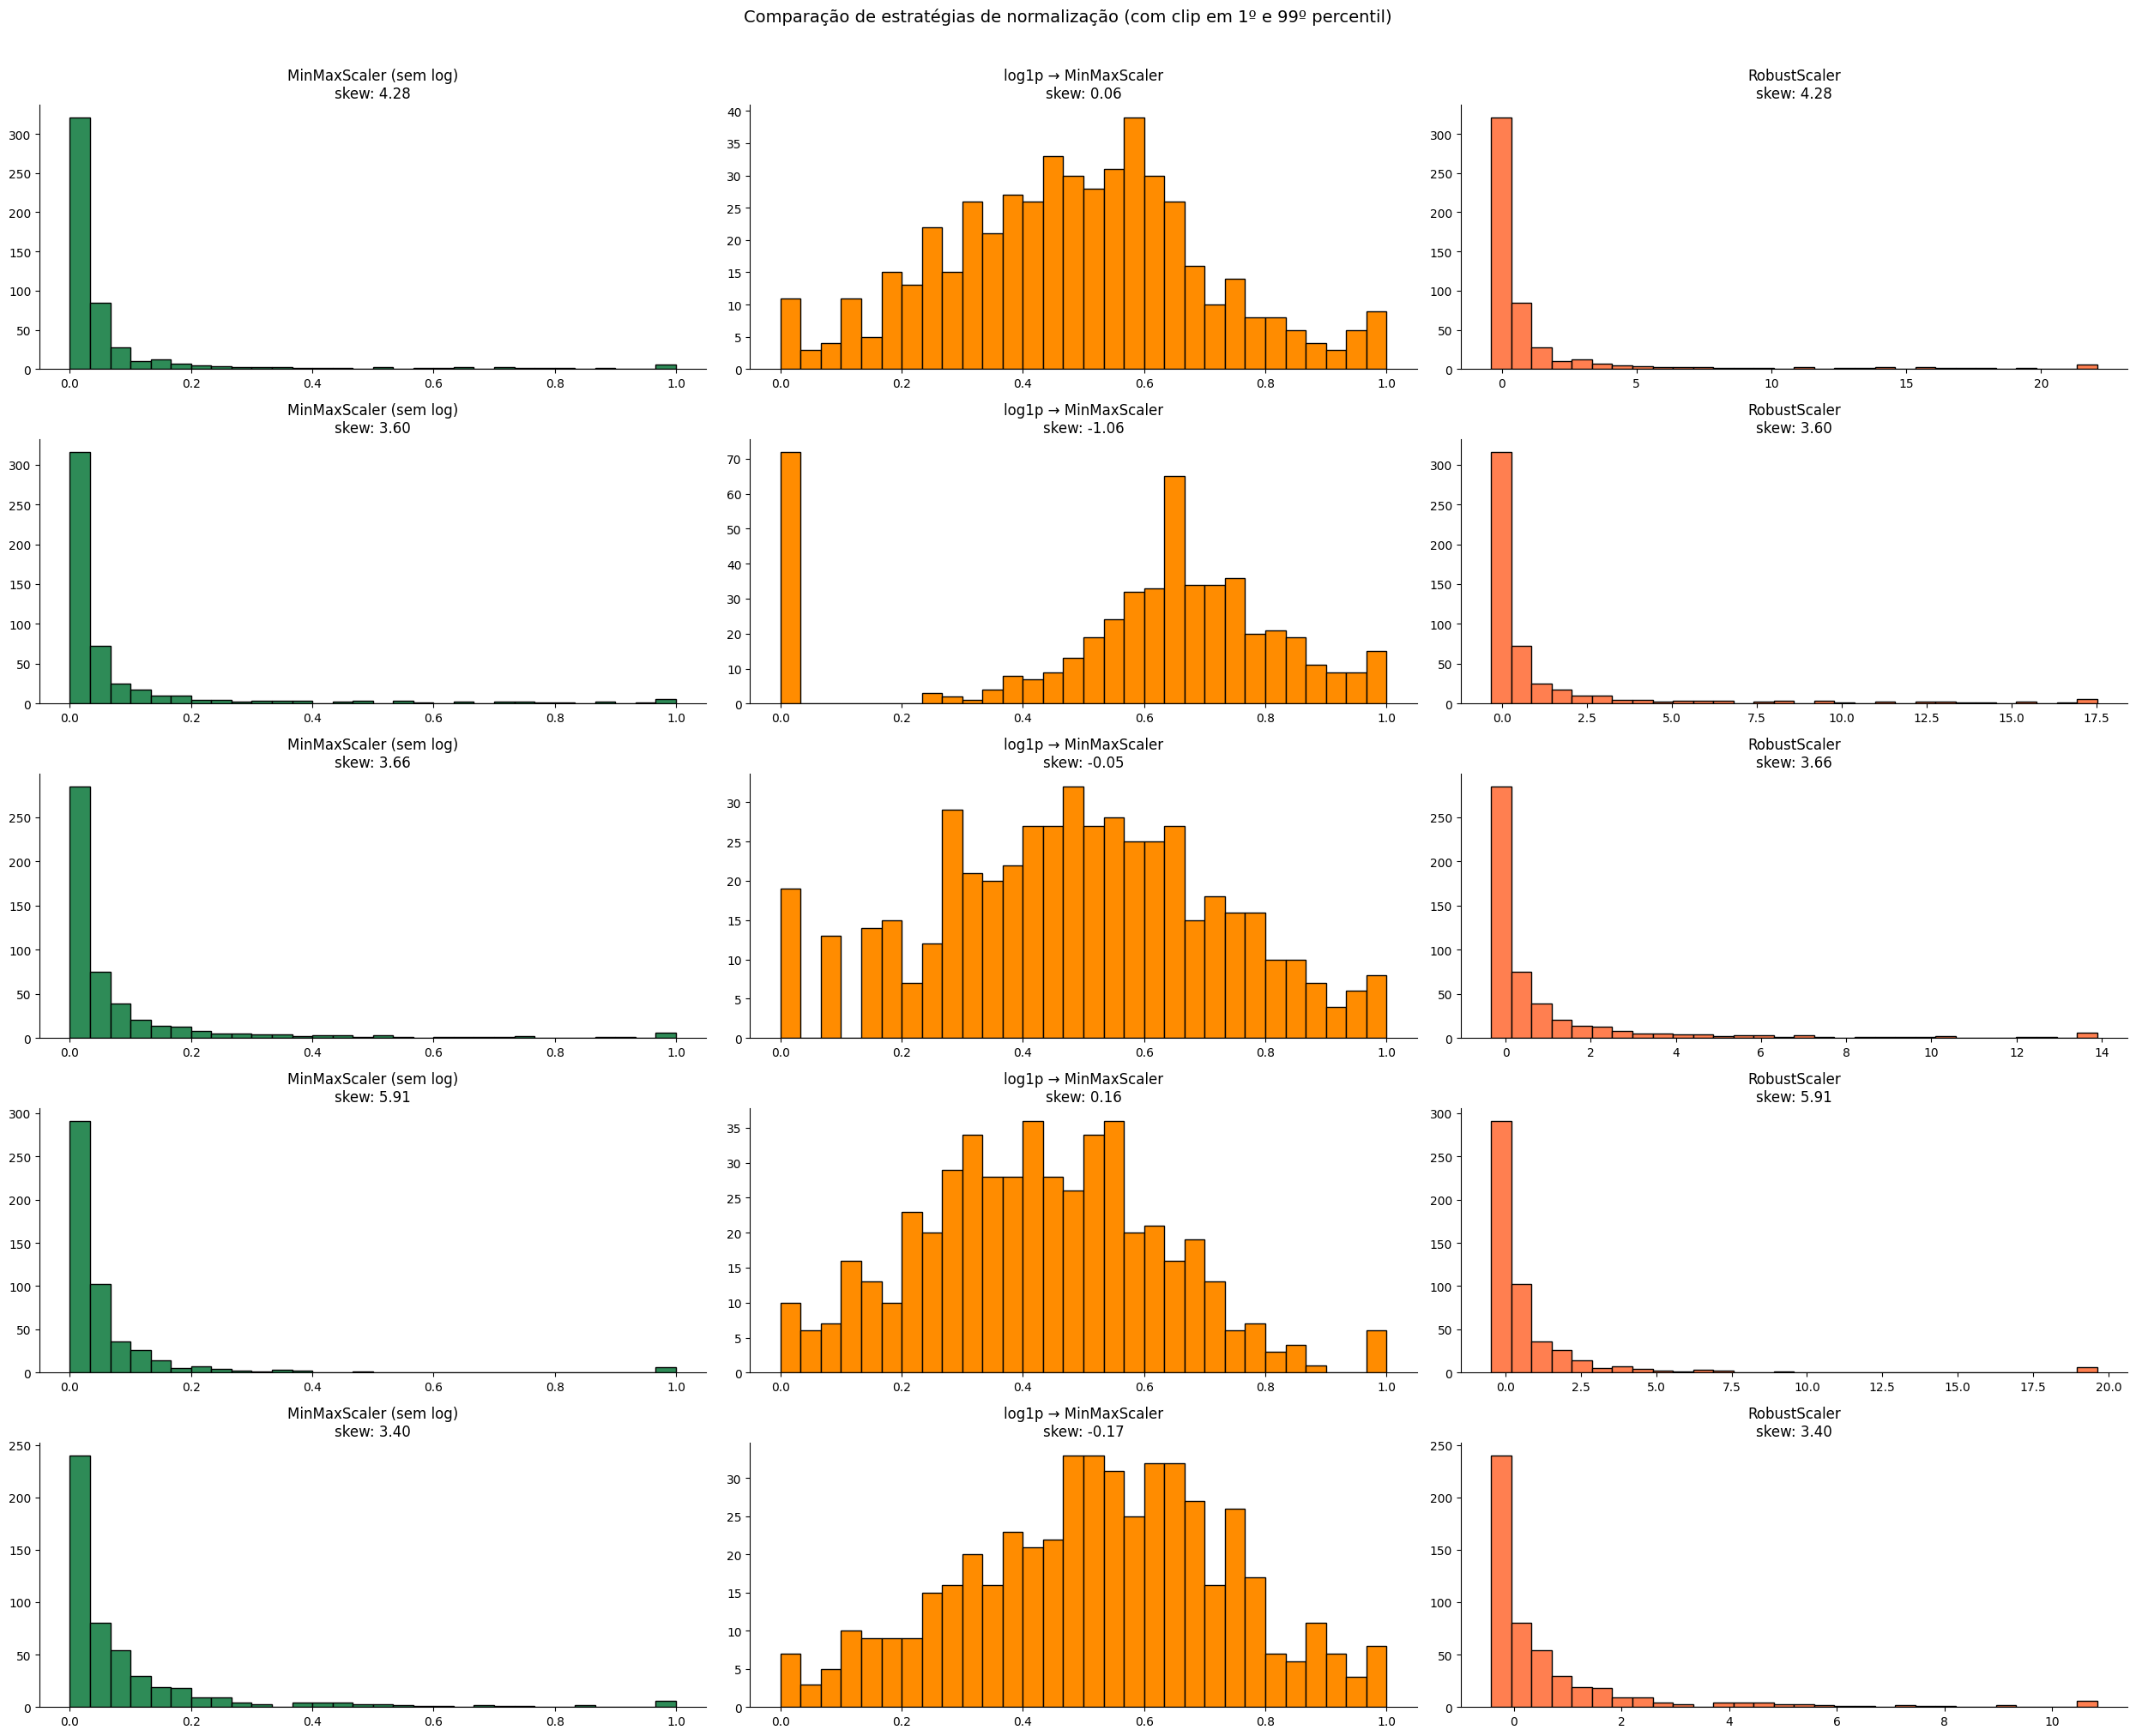

In [62]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler
import numpy as np
import matplotlib.pyplot as plt

cols = ['spend', 'revenue', 'conversions', 'impressions', 'clicks']

# Clip para limitar outliers antes de normalizar
for col in cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

fig, axes = plt.subplots(len(cols), 3, figsize=(25, 4 * len(cols)))

for i, col in enumerate(cols):
    data     = df[col].dropna().values.reshape(-1, 1)
    log_data = np.log1p(data)

    minmax_raw  = MinMaxScaler().fit_transform(data).flatten()
    minmax_log  = MinMaxScaler().fit_transform(log_data).flatten()
    robust_raw  = RobustScaler().fit_transform(data).flatten()

    skew_orig   = df[col].skew()
    skew_log    = pd.Series(log_data.flatten()).skew()
    skew_minmax = pd.Series(minmax_raw).skew()
    skew_robust = pd.Series(robust_raw).skew()

    axes[i, 0].hist(minmax_raw, bins=30, color='seagreen',   edgecolor='black')
    axes[i, 0].set_title(f'MinMaxScaler (sem log)\nskew: {skew_minmax:.2f}')

    axes[i, 1].hist(minmax_log, bins=30, color='darkorange',  edgecolor='black')
    axes[i, 1].set_title(f'log1p → MinMaxScaler\nskew: {skew_log:.2f}')

    axes[i, 2].hist(robust_raw, bins=30, color='coral',       edgecolor='black')
    axes[i, 2].set_title(f'RobustScaler\nskew: {skew_robust:.2f}')

plt.suptitle('Comparação de estratégias de normalização (com clip em 1º e 99º percentil)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [63]:

cols = ['impressions', 'clicks', 'spend', 'revenue','conversions']
scaler = MinMaxScaler()
# Clip para limitar outliers antes de normalizar
for col in cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)
for col in cols:
    # Aplica log
    log_col = np.log1p(df[col])
    # Aplica MinMax e cria nova coluna
    df[col + '_lg_mm'] = scaler.fit_transform(log_col.values.reshape(-1, 1))

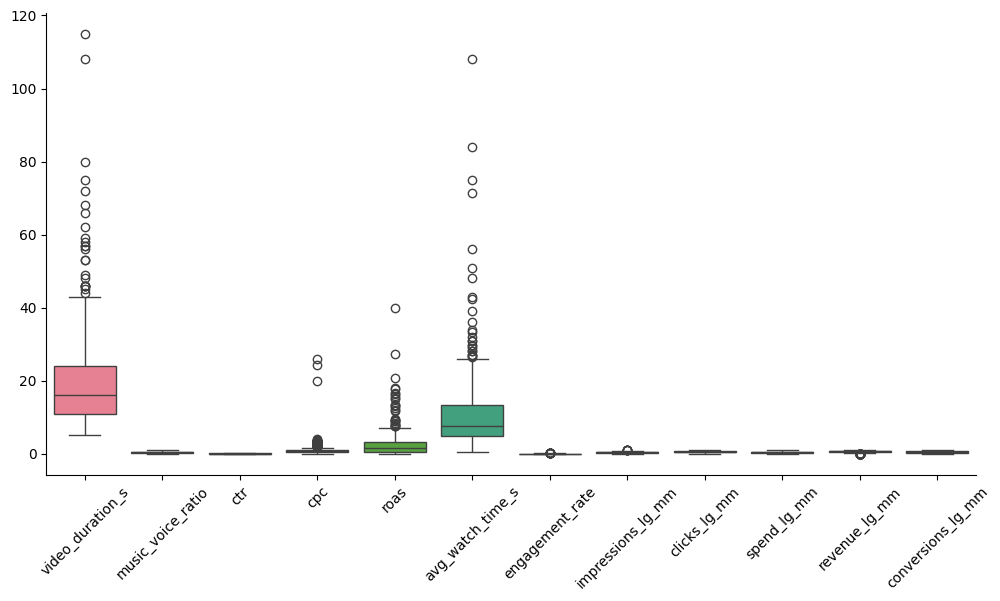

In [64]:
numeric_cols = df.select_dtypes(include='number').columns
numeric_cols = numeric_cols.drop(['spend','revenue','conversions','clicks','impressions','klike_score'])
plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)  # se os nomes forem longos
plt.show()

In [65]:
for col in ['engagement_rate', 'music_voice_ratio']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
for col in ['engagement_rate', 'music_voice_ratio']:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

In [66]:
df['klike_score'].value_counts()

klike_score
53.8    6
50.8    5
61.4    4
46.5    4
75.5    4
       ..
57.2    1
57.0    1
35.6    1
26.1    1
41.8    1
Name: count, Length: 335, dtype: int64

In [67]:
df.isna().sum()

campaign_id            0
date                   0
platform               0
category               0
objective              0
target_audience_age    0
is_retargeting         0
video_duration_s       0
format                 0
has_subtitle           0
has_cta                0
has_hook               0
has_face               0
text_density           0
music_voice_ratio      0
impressions            0
clicks                 0
ctr                    0
cpc                    0
spend                  0
conversions            0
revenue                0
roas                   0
avg_watch_time_s       0
engagement_rate        0
klike_score            0
impressions_lg_mm      0
clicks_lg_mm           0
spend_lg_mm            0
revenue_lg_mm          0
conversions_lg_mm      0
dtype: int64

In [68]:
for col in ['video_duration_s', 'avg_watch_time_s','ctr', 'roas', 'cpc']:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)
    log_col = np.log1p(df[col])
    df[col + '_lg_mm'] = scaler.fit_transform(log_col.values.reshape(-1, 1))


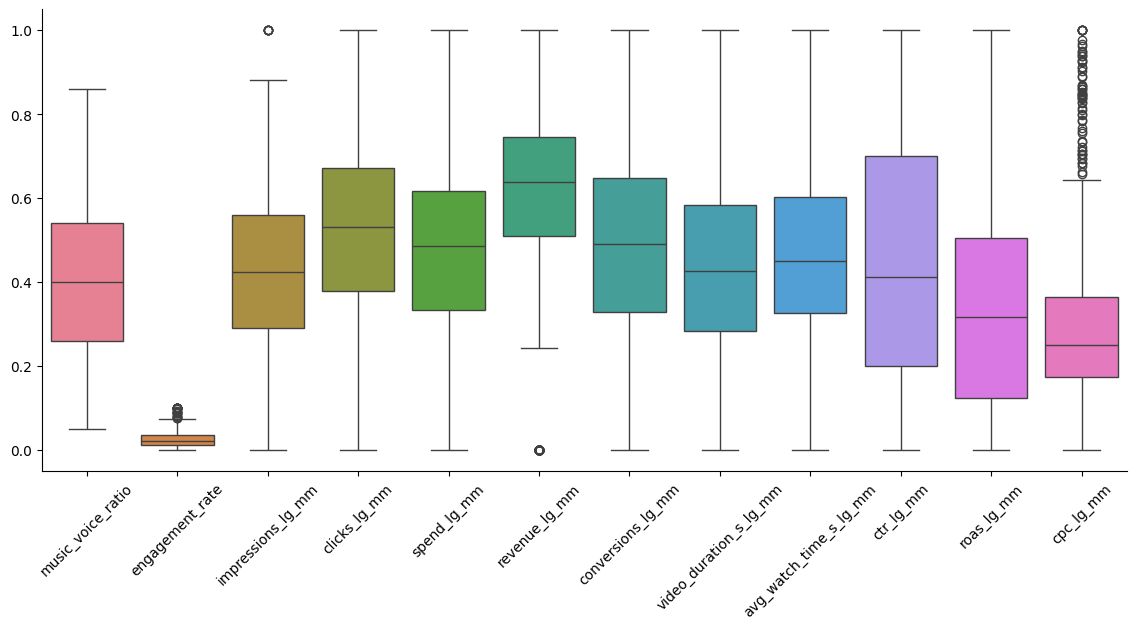

In [69]:
# Exclui as originais que têm versão normalizada, ou que nao fazem sentido serem demonstradas
cols_excluir = ['avg_watch_time_s','video_duration_s','ctr', 'roas', 'cpc','spend', 'revenue', 'conversions', 'clicks', 'impressions','klike_score']

numeric_cols = df.select_dtypes(include='number').columns
numeric_cols = [c for c in numeric_cols if c not in cols_excluir]

plt.figure(figsize=(14, 6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.show()

In [70]:
# Colunas que não entram no modelo
cols_drop = [
    # originais que têm versão normalizada
    'avg_watch_time_s','video_duration_s','ctr', 'roas', 'cpc','spend', 'revenue', 'clicks', 'impressions'
]

df_model = df.drop(columns=cols_drop, errors='ignore')

# Confirma que não sobrou nada não-numérico
print(df_model.dtypes.value_counts())
print(df_model.shape)

float64    14
str         8
bool        4
object      1
Name: count, dtype: int64
(500, 27)


### Transformar atributos relevantes em numericos ou categoricos para funcionamento do modelo

In [71]:
flags = [
    'is_retargeting', 'has_subtitle', 'has_cta', 'has_hook', 'has_face'
]

df[flags] = df[flags].astype(int)

In [72]:
df_model.dtypes

campaign_id                   str
date                          str
platform                      str
category                      str
objective                     str
target_audience_age           str
is_retargeting               bool
format                        str
has_subtitle               object
has_cta                      bool
has_hook                     bool
has_face                     bool
text_density                  str
music_voice_ratio         float64
conversions               float64
engagement_rate           float64
klike_score               float64
impressions_lg_mm         float64
clicks_lg_mm              float64
spend_lg_mm               float64
revenue_lg_mm             float64
conversions_lg_mm         float64
video_duration_s_lg_mm    float64
avg_watch_time_s_lg_mm    float64
ctr_lg_mm                 float64
roas_lg_mm                float64
cpc_lg_mm                 float64
dtype: object

In [73]:
df['platform']

0          Meta
1      LinkedIn
2        TikTok
3        TikTok
4          Meta
         ...   
495        Meta
496      TikTok
497        Meta
498    LinkedIn
499    LinkedIn
Name: platform, Length: 500, dtype: str

In [74]:
# Salva a plataforma original
df_model['platform_holder'] = df_model['platform']
df_model['text_density_holder'] = df_model['text_density']
df_model['format_holder'] = df_model['format']
# Cria os dummies e mantém a original
df_model = pd.get_dummies(
    df_model, 
    columns=['platform','text_density','format'], 
    prefix=['platform','text_density','format']
)
# Renomeia a coluna auxiliar de volta para 'platform'
df_model.rename(columns={'platform_holder': 'platform','text_density_holder':'text_density','format_holder':'format'}, inplace=True)
df_model['has_subtitle'] = df_model['has_subtitle'].astype(int)

In [75]:
df_model.to_csv('./data/df_model.csv', index=False)

In [76]:
df_model.columns


Index(['campaign_id', 'date', 'category', 'objective', 'target_audience_age',
       'is_retargeting', 'has_subtitle', 'has_cta', 'has_hook', 'has_face',
       'music_voice_ratio', 'conversions', 'engagement_rate', 'klike_score',
       'impressions_lg_mm', 'clicks_lg_mm', 'spend_lg_mm', 'revenue_lg_mm',
       'conversions_lg_mm', 'video_duration_s_lg_mm', 'avg_watch_time_s_lg_mm',
       'ctr_lg_mm', 'roas_lg_mm', 'cpc_lg_mm', 'platform', 'text_density',
       'format', 'platform_LinkedIn', 'platform_Meta', 'platform_TikTok',
       'text_density_high', 'text_density_low', 'text_density_medium',
       'format_horizontal', 'format_quadrado', 'format_vertical'],
      dtype='str')

In [77]:
df_model.columns

Index(['campaign_id', 'date', 'category', 'objective', 'target_audience_age',
       'is_retargeting', 'has_subtitle', 'has_cta', 'has_hook', 'has_face',
       'music_voice_ratio', 'conversions', 'engagement_rate', 'klike_score',
       'impressions_lg_mm', 'clicks_lg_mm', 'spend_lg_mm', 'revenue_lg_mm',
       'conversions_lg_mm', 'video_duration_s_lg_mm', 'avg_watch_time_s_lg_mm',
       'ctr_lg_mm', 'roas_lg_mm', 'cpc_lg_mm', 'platform', 'text_density',
       'format', 'platform_LinkedIn', 'platform_Meta', 'platform_TikTok',
       'text_density_high', 'text_density_low', 'text_density_medium',
       'format_horizontal', 'format_quadrado', 'format_vertical'],
      dtype='str')

In [78]:
df_model['video_duration_s'] = df['video_duration_s']

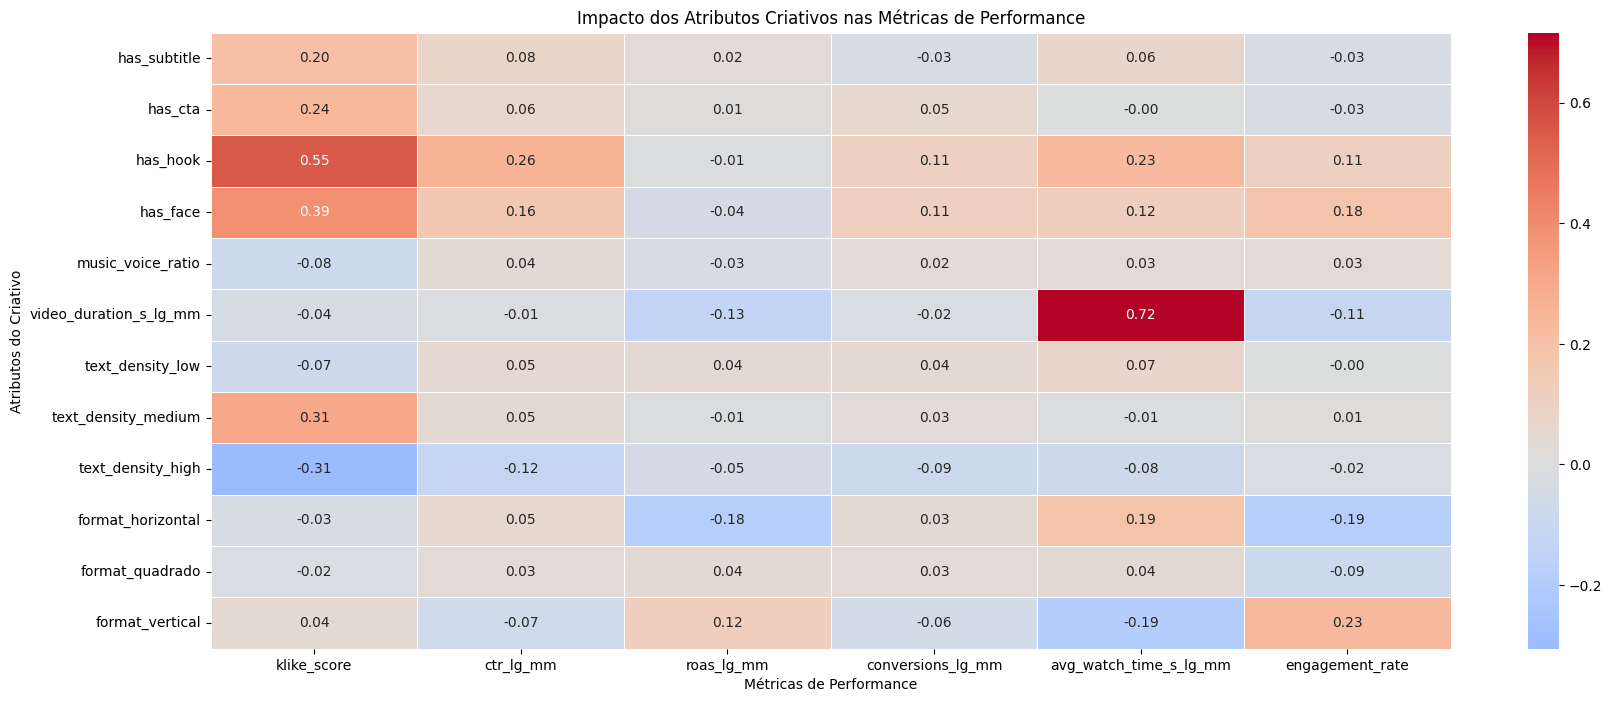

In [79]:
performance_cols = [
    'klike_score',
    'ctr_lg_mm',
    'roas_lg_mm',
    'conversions_lg_mm',
    'avg_watch_time_s_lg_mm',
    'engagement_rate'
]
numeric_creative = [
    'has_subtitle',
    'has_cta',
    'has_hook',
    'has_face',
    'music_voice_ratio',
    'video_duration_s_lg_mm',
    'text_density_low',
    'text_density_medium',
    'text_density_high',
    'format_horizontal',
    'format_quadrado',
    'format_vertical'
]

corr = df_model[numeric_creative + performance_cols].corr()

plt.figure(figsize=(20,8))

sns.heatmap(
    corr.loc[numeric_creative, performance_cols],
    annot=True,
    fmt=".2f",
    center=0,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Impacto dos Atributos Criativos nas Métricas de Performance")
plt.ylabel("Atributos do Criativo")
plt.xlabel("Métricas de Performance")

plt.show()

In [80]:
df_model['platform_LinkedIn']

0      False
1       True
2      False
3      False
4      False
       ...  
495    False
496    False
497    False
498     True
499     True
Name: platform_LinkedIn, Length: 500, dtype: bool

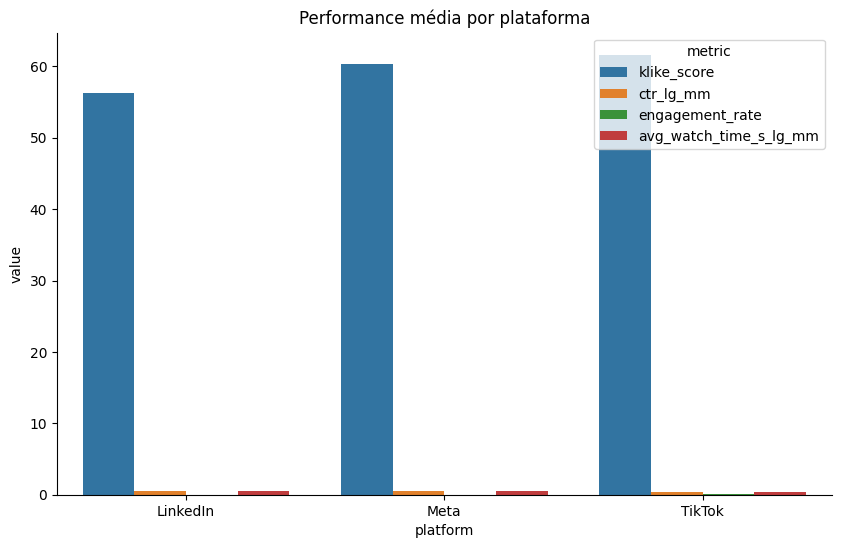

In [81]:
platform_metrics = [
    'klike_score',
    'ctr_lg_mm',
    'engagement_rate',
    'avg_watch_time_s_lg_mm'
]

df_platform = (
    df_model
    .groupby('platform')[platform_metrics]
    .mean()
    .reset_index()
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(
    data=df_platform.melt(
        id_vars='platform',
        var_name='metric',
        value_name='value'
    ),
    x='platform',
    y='value',
    hue='metric'
)

plt.title("Performance média por plataforma")
plt.show()

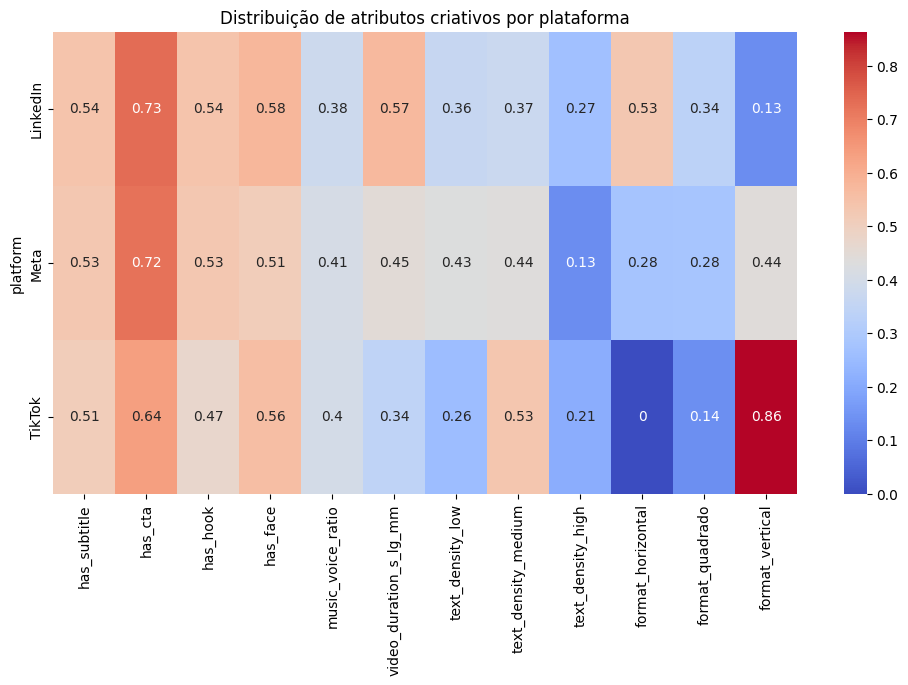

In [82]:
creative_cols = [
    'has_subtitle',
    'has_cta',
    'has_hook',
    'has_face',
    'music_voice_ratio',
    'video_duration_s_lg_mm',
    'text_density_low',
    'text_density_medium',
    'text_density_high',
    'format_horizontal',
    'format_quadrado',
    'format_vertical'
]

plt.figure(figsize=(12,6))

sns.heatmap(
    df_model.groupby('platform')[creative_cols].mean(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Distribuição de atributos criativos por plataforma")
plt.show()

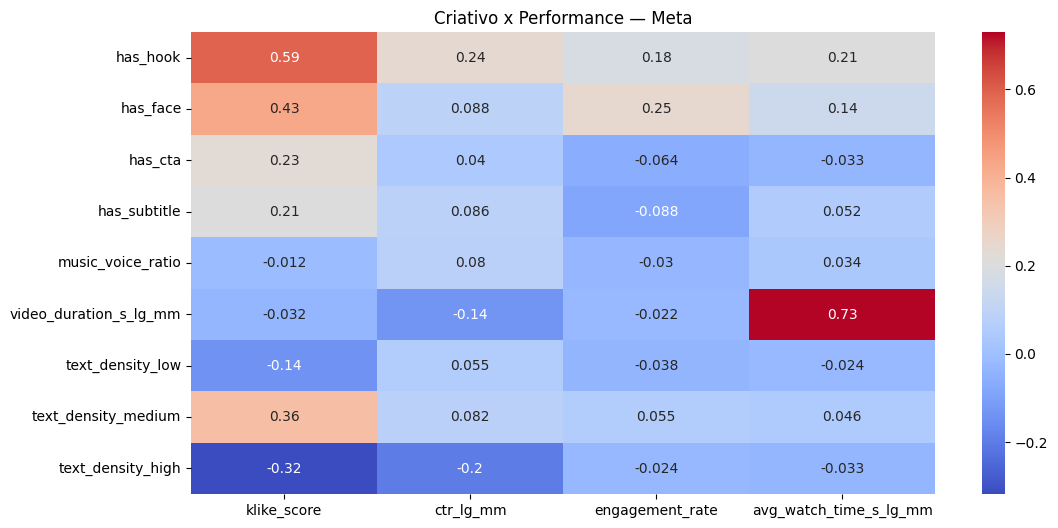

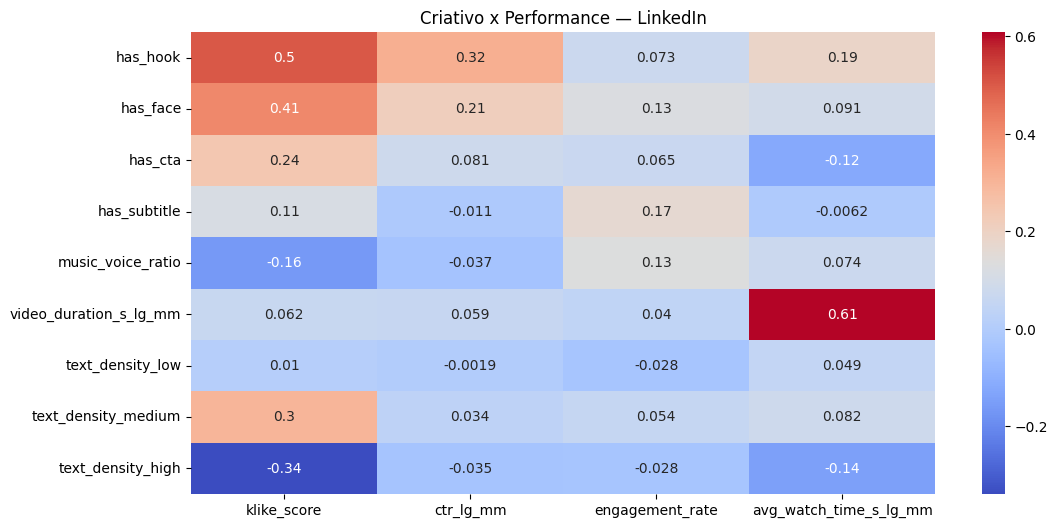

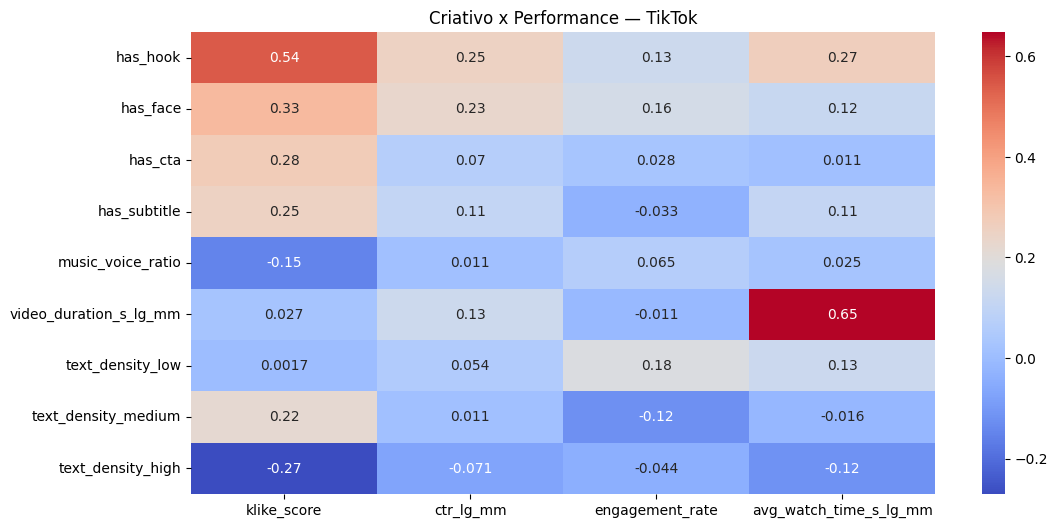

In [83]:
creative_cols = [
    'has_hook',
    'has_face',
    'has_cta',
    'has_subtitle',
    'music_voice_ratio',
    'video_duration_s_lg_mm',
    'text_density_low',
    'text_density_medium',
    'text_density_high'
]

performance_cols = [
    'klike_score',
    'ctr_lg_mm',
    'engagement_rate',
    'avg_watch_time_s_lg_mm'
]

for platform in df_model['platform'].unique():

    df_p = df_model[df_model['platform'] == platform]

    corr = df_p[creative_cols + performance_cols].corr()

    plt.figure(figsize=(12,6))
    sns.heatmap(
        corr.loc[creative_cols, performance_cols],
        annot=True,
        cmap='coolwarm'
    )

    plt.title(f"Criativo x Performance — {platform}")
    plt.show()

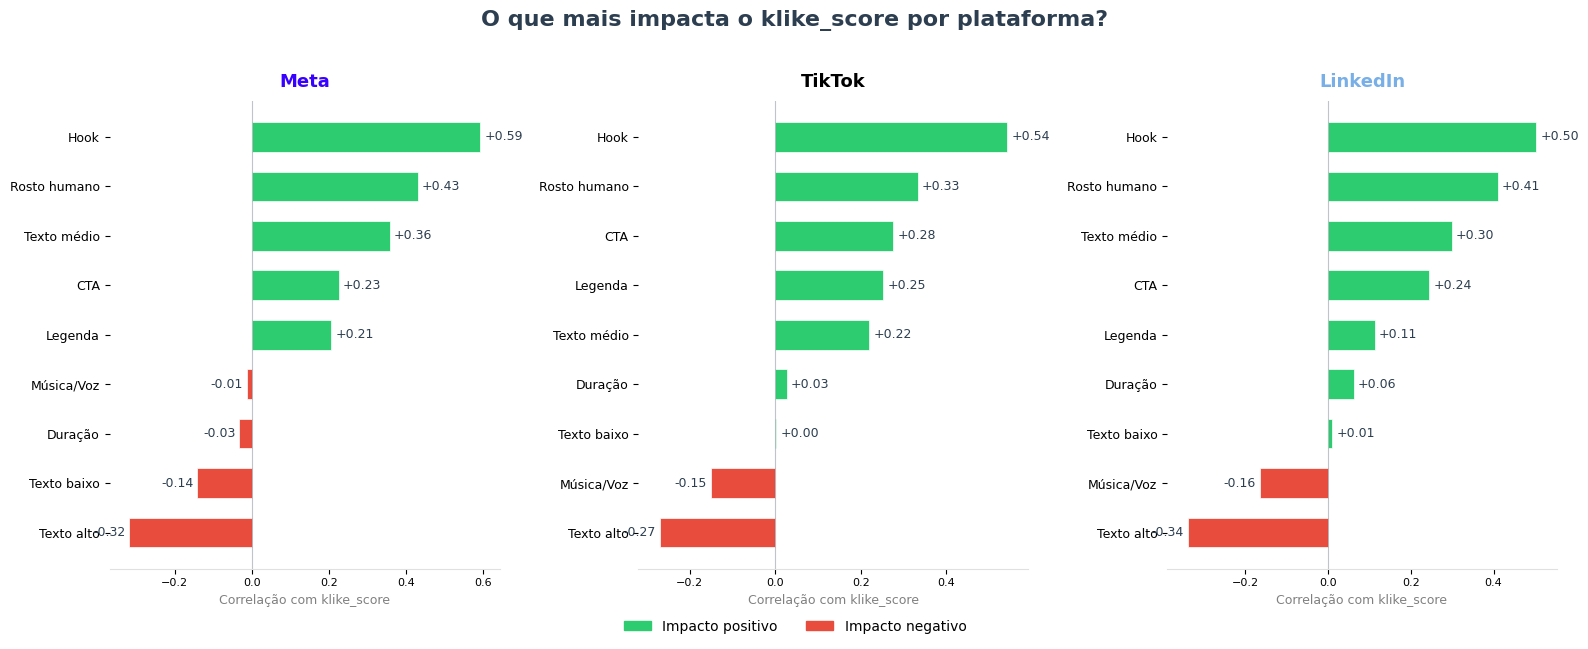

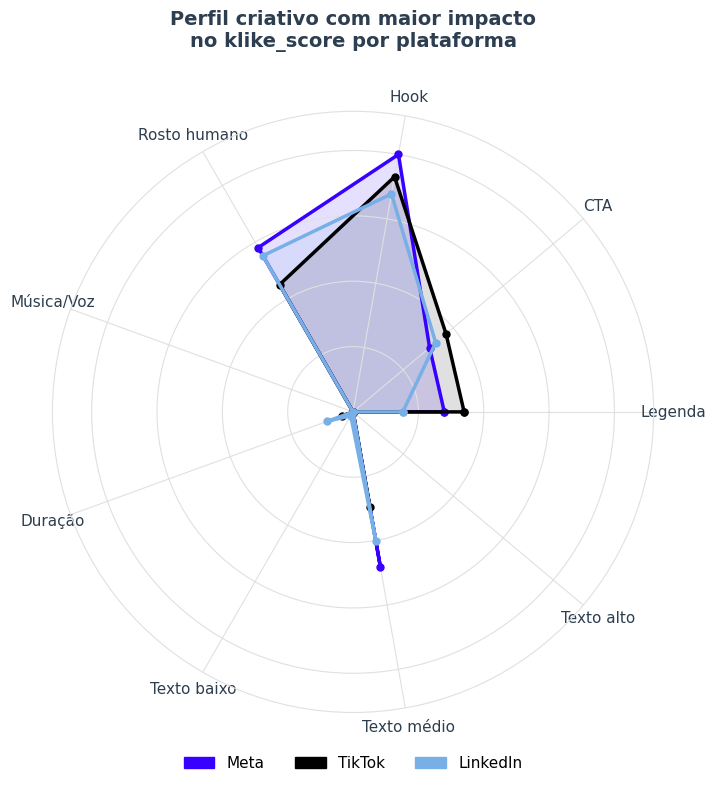

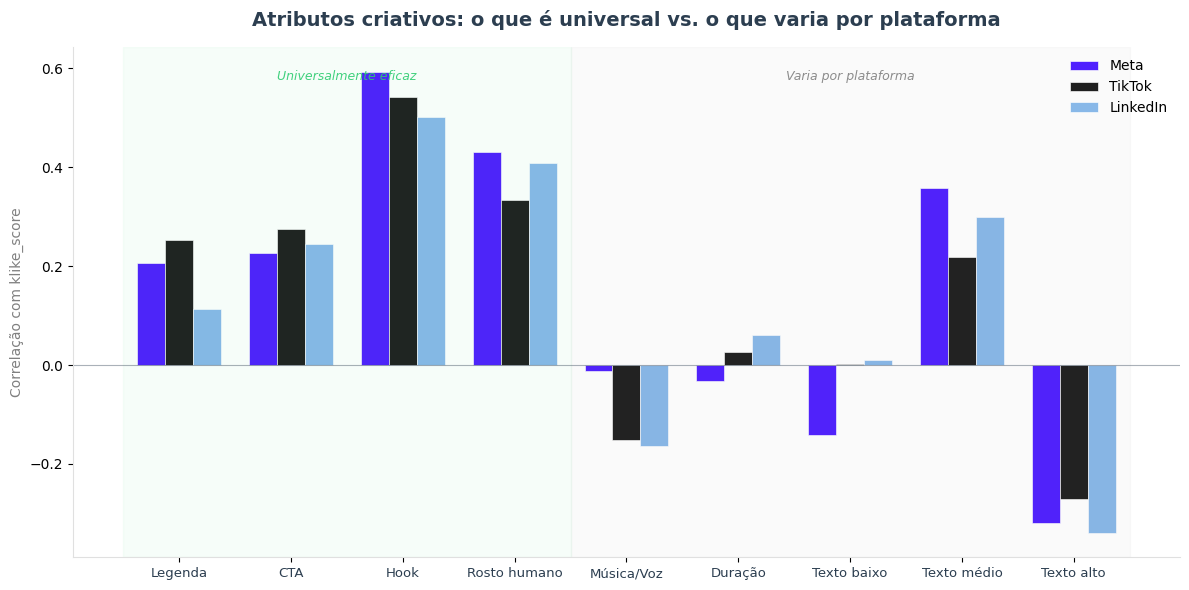

In [84]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# ── CORES ──────────────────────────────────────────────
COLORS = {
    'TikTok':  '#69C9D0',
    'Meta':    '#4267B2',
    'LinkedIn':'#0A66C2',
    'positive':'#2ECC71',
    'negative':'#E74C3C',
    'neutral': '#BDC3C7',
    'bg':      '#F8F9FA',
    'text':    '#2C3E50',
}

# ── ATRIBUTOS PARA LABELS ─────────────────────────────
ATTR_LABELS = {
    'has_hook':            'Hook',
    'has_face':            'Rosto humano',
    'has_cta':             'CTA',
    'has_subtitle':        'Legenda',
    'music_voice_ratio':   'Música/Voz',
    'video_duration_s_lg_mm': 'Duração',
    'text_density_low':    'Texto baixo',
    'text_density_medium': 'Texto médio',
    'text_density_high':   'Texto alto',
}

# ── COLUNAS ──────────────────────────────────────────
performance_cols = [
    'klike_score',
    'ctr_lg_mm',
    'roas_lg_mm',
    'conversions_lg_mm',
    'avg_watch_time_s_lg_mm',
    'engagement_rate'
]

numeric_creative = [
    'has_subtitle',
    'has_cta',
    'has_hook',
    'has_face',
    'music_voice_ratio',
    'video_duration_s_lg_mm',
    'text_density_low',
    'text_density_medium',
    'text_density_high'
]

platforms = ['Meta', 'TikTok', 'LinkedIn']
plat_colors = {'Meta': "#3700FF", 'TikTok': "#000000", 'LinkedIn': "#78AFE6"}

# ── CALCULA CORRELAÇÕES COM KLIKE_SCORE ──────────────
klike_corr_auto = {}
for plat in platforms:
    df_plat = df_model[df_model['platform'] == plat]
    corr = df_plat[numeric_creative + ['klike_score']].corr()
    klike_corr_auto[plat] = {attr: corr.loc[attr, 'klike_score'] for attr in numeric_creative}

# ── VIZ 1: Ranking de impacto no klike_score ─────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6), facecolor='white')
fig.suptitle('O que mais impacta o klike_score por plataforma?',
             fontsize=16, fontweight='bold', color=COLORS['text'], y=1.02)

for ax, plat in zip(axes, platforms):
    data = klike_corr_auto[plat]
    items = sorted(data.items(), key=lambda x: x[1])
    labels = [ATTR_LABELS[k] for k, _ in items]
    values = [v for _, v in items]
    bar_colors = [COLORS['positive'] if v >= 0 else COLORS['negative'] for v in values]

    bars = ax.barh(labels, values, color=bar_colors, height=0.6,
                   edgecolor='white', linewidth=0.5)

    for bar, val in zip(bars, values):
        x = val + 0.01 if val >= 0 else val - 0.01
        ha = 'left' if val >= 0 else 'right'
        ax.text(x, bar.get_y() + bar.get_height() / 2,
                f'{val:+.2f}', va='center', ha=ha, fontsize=9,
                color=COLORS['text'], fontweight='500')

    ax.axvline(0, color=COLORS['text'], linewidth=0.8, alpha=0.3)
    ax.set_xlim(min(values) - 0.05, max(values) + 0.05)
    ax.set_title(plat, fontsize=13, fontweight='bold', color=plat_colors[plat], pad=10)
    ax.tick_params(axis='y', labelsize=9)
    ax.tick_params(axis='x', labelsize=8)
    ax.set_xlabel('Correlação com klike_score', fontsize=9, color='gray')
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color('#E0E0E0')

pos_patch = mpatches.Patch(color=COLORS['positive'], label='Impacto positivo')
neg_patch = mpatches.Patch(color=COLORS['negative'], label='Impacto negativo')
fig.legend(handles=[pos_patch, neg_patch], loc='lower center',
           ncol=2, fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.show()

# ── VIZ 2: Radar — perfil criativo ideal por plataforma ─
labels_radar = [ATTR_LABELS[a] for a in numeric_creative]
radar_data = {plat: [max(0, klike_corr_auto[plat][a]) for a in numeric_creative] for plat in platforms}
vmax = max(v for d in radar_data.values() for v in d)
radar_data_norm = {p: [v / vmax for v in vals] for p, vals in radar_data.items()}

N = len(numeric_creative)
angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True), facecolor='white')
ax.set_facecolor('white')

for plat, color in plat_colors.items():
    vals = radar_data_norm[plat] + radar_data_norm[plat][:1]
    ax.plot(angles, vals, 'o-', linewidth=2.5, color=color, label=plat, markersize=5)
    ax.fill(angles, vals, alpha=0.12, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, size=11, color=COLORS['text'], fontweight='500')
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels([])
ax.set_ylim(0, 1.15)
ax.grid(color='#E0E0E0', linewidth=0.8)
ax.spines['polar'].set_color('#E0E0E0')
ax.set_title('Perfil criativo com maior impacto\nno klike_score por plataforma',
             fontsize=14, fontweight='bold', color=COLORS['text'], pad=25, y=1.05)

handles = [mpatches.Patch(color=plat_colors[p], label=p) for p in platforms]
ax.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.12),
          ncol=3, fontsize=11, frameon=False)

plt.tight_layout()
plt.show()

# ── VIZ 3: Universal vs. específico por plataforma ─
fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')
ax.set_facecolor('white')

x = np.arange(len(numeric_creative))
width = 0.25

for i, (plat, color) in enumerate(plat_colors.items()):
    vals = [klike_corr_auto[plat][a] for a in numeric_creative]
    ax.bar(x + (i - 1) * width, vals, width, label=plat, color=color,
           alpha=0.88, edgecolor='white', linewidth=0.5)

ax.axhline(0, color=COLORS['text'], linewidth=0.8, alpha=0.4)
ax.axvspan(-0.5, 3.5, alpha=0.04, color=COLORS['positive'])
ax.axvspan(3.5, len(numeric_creative)-0.5, alpha=0.04, color='gray')
ax.text(1.5, max(ax.get_ylim())*0.9, 'Universalmente eficaz', ha='center', fontsize=9,
        color=COLORS['positive'], fontstyle='italic', alpha=0.9)
ax.text(6.0, max(ax.get_ylim())*0.9, 'Varia por plataforma', ha='center', fontsize=9,
        color='gray', fontstyle='italic', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels([ATTR_LABELS[a] for a in numeric_creative], fontsize=9.5, color=COLORS['text'])
ax.set_ylabel('Correlação com klike_score', fontsize=10, color='gray')
ax.set_ylim(min([v for d in klike_corr_auto.values() for v in d.values()]) - 0.05,
            max([v for d in klike_corr_auto.values() for v in d.values()]) + 0.05)
ax.legend(fontsize=10, frameon=False, loc='upper right')
ax.set_title('Atributos criativos: o que é universal vs. o que varia por plataforma',
             fontsize=14, fontweight='bold', color=COLORS['text'], pad=15)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('#E0E0E0')
ax.spines['left'].set_visible(True)
ax.spines['left'].set_color('#E0E0E0')

plt.tight_layout()
plt.show()